# [Test] Read and process the light data of a config run

The goal is to be able to display the waveforms recorded during cablibration run and make finger plots.

## Test data

We took some test data and then we were able to flow them on `neutrino01`, on the ndlar-flow `develop` branch: 
> (ndlar_flow.venv) [nsallin@neutrino01 ndlar_flow]$ h5flow -c yamls/fsd_flow/workflows/light/light_event_building_mpd.yaml -i /storage/data/LRS/20250507_testCalibWarm_1/mpd_run_calib_rctl_041.data -o /terabig/nsallin/data/test_ndlar_flow/20250516_test1.FLOW.h5
WARNING:root:Running without mpi4py because No module named 'mpi4py'
>~~~ H5FLOW ~~~
>output file: /terabig/nsallin/data/test_ndlar_flow/20250516_test1.FLOW.h5
>input file: /storage/data/LRS/20250507_testCalibWarm_1/mpd_run_calib_rctl_041.data
>~~~~~~~~~~~~~~
>
>~~~ WORKFLOW ~~~
>yamls/fsd_flow/workflows/light/light_event_building_mpd.yaml
>~~~~~~~~~~~~~~~~
>
>~~~ INIT ~~~
>Hello
>create LightMPDEventGenerator(light/events) /storage/data/LRS/20250507_testCalibWarm_1/mpd_run_calib_rctl_041.data
>LightMPDEventGenerator.init()
>~~~~~~~~~~~~
>
>~~~ RUN ~~~
>Run loop on light/events:
>
>100%|>##########################################################################################################################################>###############################################################| 15/15 [00:01<00:00, 10.15it/s]
>~~~~~~~~~~~
>
>~~~ FINISH ~~~
>LightMPDEventGenerator.finish()
>~~~~~~~~~~~~~~

## Display
Now with the help of this notebook we will plot them and store them in the form of a png.

In [8]:
import h5py

In [9]:
# First get the data
d = '/Users/nsallin/develop/data/FSD/test_ndlar_flow/'
f = '20250516_test1.FLOW.h5'

In [10]:
f_h5 = h5py.File(d+f)
print('The file keys are:\n')
print(f_h5.keys(), '\n')

The file keys are:

<KeysViewHDF5 ['light']> 



In [11]:
print(f_h5['light'].keys())

<KeysViewHDF5 ['events', 'wvfm']>


In [12]:
%load_ext autoreload

%autoreload 2

from calibWvfms import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
wvfms = calibWvfms(filedir = d, filename = f)

Processing file /Users/nsallin/develop/data/FSD/test_ndlar_flow/20250516_test1.FLOW.h5
The output path is set to /Users/nsallin/develop/calibFSD/evD_20250516_test1.FLOW.h5/
Number of events in the selection: 180


In [14]:
len(wvfms.light_wvfms[12][0,0])
print(wvfms.light_wvfms.shape)

(180, 4, 64, 600)


 There are 29 triggers with a threshold at -27600


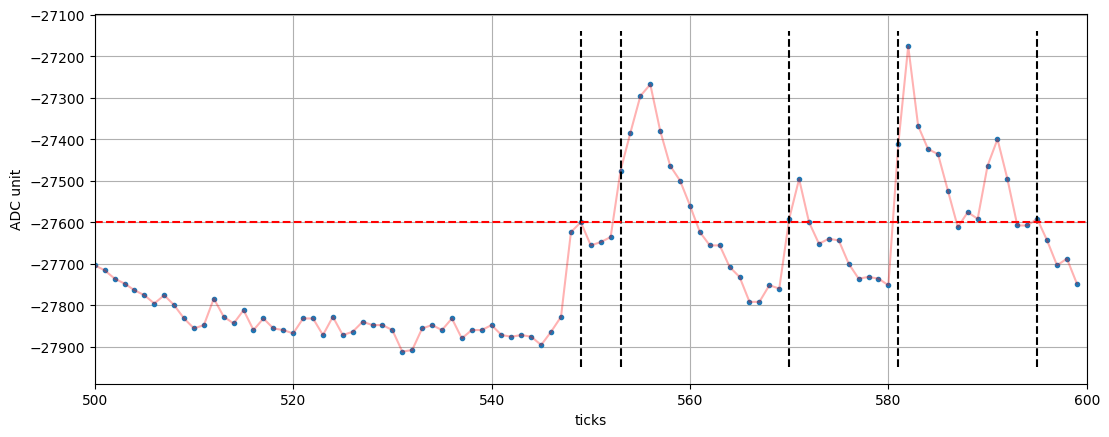

In [15]:
wvfms.plot_wvfms(13, 0, 10, (500,600), -27600)

28 peaks were found above the mean with a minWidth of 9 and 16 were cut out.


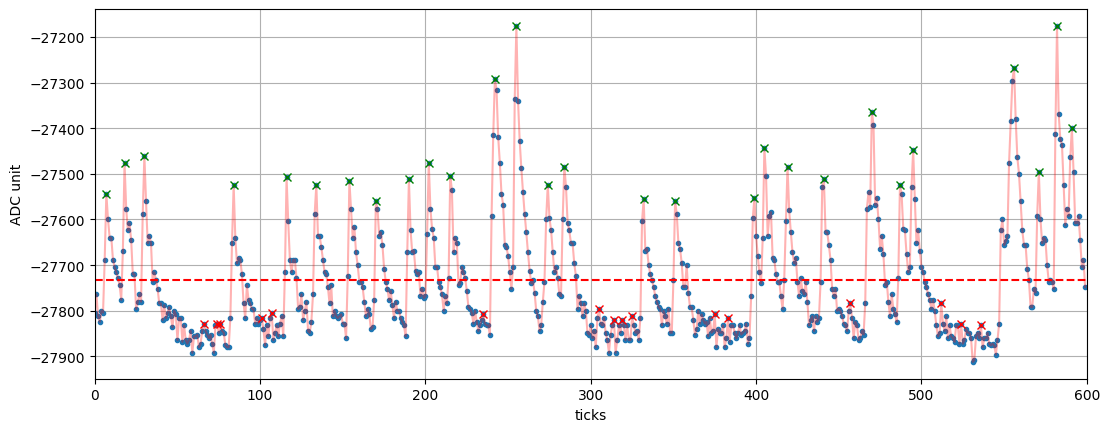

In [16]:
wvfms.plot_wvfms(13, 0, 10, (00,600), peakFinder=True, minWidth=9, verbose=True)

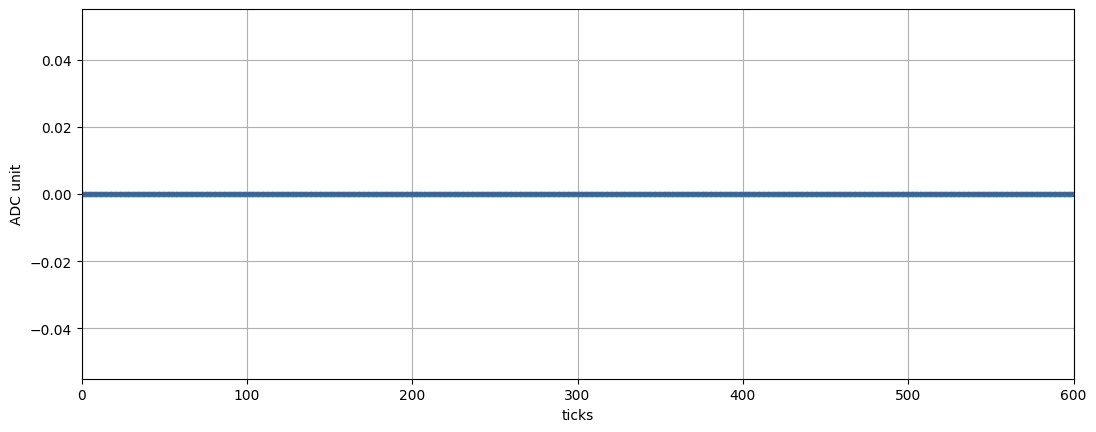

In [17]:
wvfms.plot_wvfms(13, 0, 63, (00,600))

In [18]:
wvfms.Npeaks[13, 0, 10]

np.float64(28.0)

Now we want to run over all events, for all channels and compute then plot the DC rate


In [19]:
Nevent, Nadc, Nchan, Nticks = wvfms.light_wvfms.shape

print(Nevent, Nadc, Nchan)


180 4 64


In [20]:
for event in range(Nevent):
    for adc in range(Nadc):
        for chan in range(Nchan):
            wvfms.findPeak_wvfms(event, adc, chan, minWidth=9)

print(wvfms.Npeaks)

[[[29. 32. 19. ... 23.  0.  0.]
  [32. 19. 40. ... 28.  0.  0.]
  [29. 27. 33. ... 30.  0.  0.]
  [30. 32. 26. ... 28.  0.  0.]]

 [[27. 34. 29. ... 24.  0.  0.]
  [25. 22. 33. ... 39.  0.  0.]
  [23. 26. 31. ... 22.  0.  0.]
  [25. 35. 30. ... 22.  0.  0.]]

 [[19. 30. 29. ... 23.  0.  0.]
  [31. 19. 27. ... 38.  0.  0.]
  [33. 28. 27. ... 30.  0.  0.]
  [33. 36. 29. ... 21.  0.  0.]]

 ...

 [[26. 26. 24. ... 30.  0.  0.]
  [29. 26. 39. ... 35.  0.  0.]
  [34. 30. 36. ... 17.  0.  0.]
  [28. 33. 34. ... 28.  0.  0.]]

 [[30. 32. 23. ... 25.  0.  0.]
  [28. 30. 34. ... 26.  0.  0.]
  [29. 26. 35. ... 21.  0.  0.]
  [24. 34. 25. ... 25.  0.  0.]]

 [[24. 33. 26. ... 28.  0.  0.]
  [29. 28. 32. ... 28.  0.  0.]
  [27. 27. 30. ... 12.  0.  0.]
  [26. 30. 35. ... 30.  0.  0.]]]


In [21]:
peaks_sum = np.sum(wvfms.Npeaks, axis=0)
# print(sum, sum.shape)
DC_rates = peaks_sum/(Nevent*600*wvfms.time_tick)

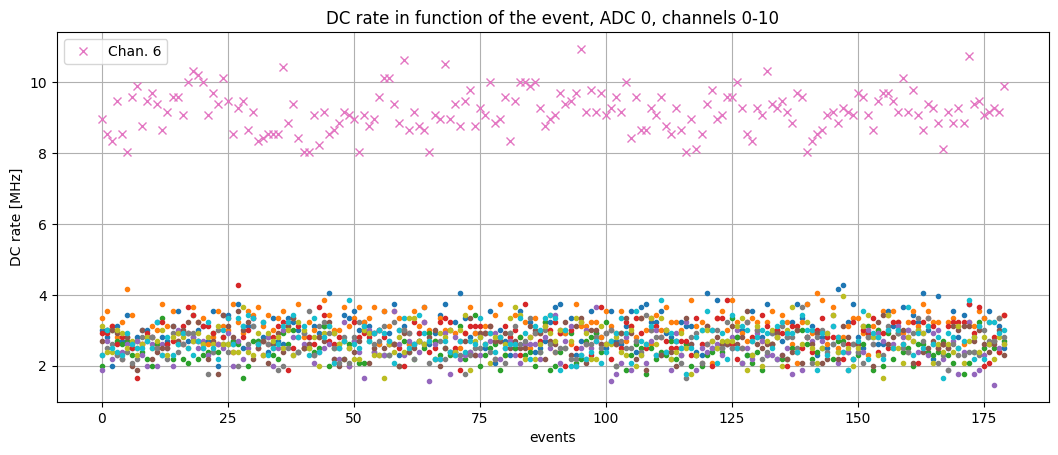

In [22]:
fig_DCrate_events = plt.figure(figsize=[12.8, 4.8])
ax_DCrate_events = fig_DCrate_events.subplots()

ax_DCrate_events.set_xlabel('events')
ax_DCrate_events.set_ylabel('DC rate [MHz]')
ax_DCrate_events.grid(True)

leg_list=[]

for event in range(Nevent):
    for adc in range(1):
        for chan in range(10):
            if (wvfms.Npeaks[event,adc,chan]*10**-6/(600*wvfms.time_tick)<8):
                ax_DCrate_events.plot(event, wvfms.Npeaks[event,adc,chan]*10**-6/(600*wvfms.time_tick), marker='.')
            else:
                if (np.isin(chan, leg_list)==False):
                    ax_DCrate_events.plot(event, wvfms.Npeaks[event,adc,chan]*10**-6/(600*wvfms.time_tick), marker='x', ls='', label=f'Chan. {chan}')
                    leg_list.append(chan)
                else:
                    ax_DCrate_events.plot(event, wvfms.Npeaks[event,adc,chan]*10**-6/(600*wvfms.time_tick), marker='x')

ax_DCrate_events.set_title('DC rate in function of the event, ADC 0, channels 0-10')
ax_DCrate_events.legend()

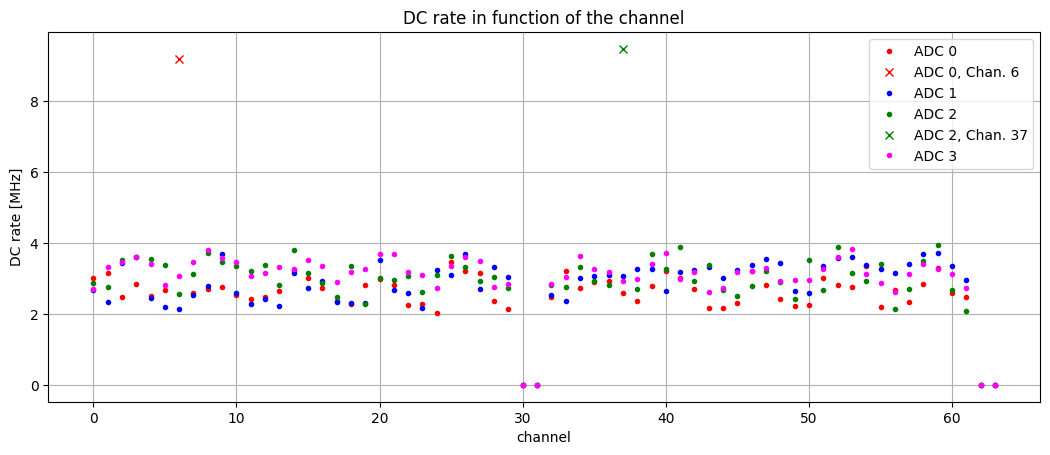

In [23]:
fig_DCrate_chan = plt.figure(figsize=[12.8, 4.8])
ax_DCrate_chan = fig_DCrate_chan.subplots()

ax_DCrate_chan.set_xlabel('channel')
ax_DCrate_chan.set_ylabel('DC rate [MHz]')
ax_DCrate_chan.grid(True)

colors=['red', 'blue', 'green', 'magenta']

for adc in range(Nadc):
    is_leg_ADC=False
    for chan in range(Nchan):
        if (DC_rates[adc,chan] > 5*10**6):
            ax_DCrate_chan.plot(chan, DC_rates[adc,chan]*10**-6, marker='x', ls='', color=colors[adc], label=f'ADC {adc}, Chan. {chan}')
        else:
            if is_leg_ADC==True:
                ax_DCrate_chan.plot(chan, DC_rates[adc,chan]*10**-6, marker='.', ls='', color=colors[adc])
            else:
                ax_DCrate_chan.plot(chan, DC_rates[adc,chan]*10**-6, marker='.', ls='', color=colors[adc], label=f'ADC {adc}')
                is_leg_ADC=True
            

# ax_DCrate_chan.set_ylim(2,4)
ax_DCrate_chan.set_title('DC rate in function of the channel')
ax_DCrate_chan.legend()

If we look in details, the chan. 6 of ADC 0 and chan. 37 of ADC 2 are not very noisy but are probably not connected

In [24]:
wvfms2 = calibWvfms(filedir = d, filename = f)

Processing file /Users/nsallin/develop/data/FSD/test_ndlar_flow/20250516_test1.FLOW.h5
The output path is set to /Users/nsallin/develop/calibFSD/evD_20250516_test1.FLOW.h5/
Number of events in the selection: 180


In [25]:
for event in range(Nevent):
    for adc in range(Nadc):
        for chan in range(Nchan):
            wvfms2.findPeak_wvfms(event, adc, chan, minWidth=5)


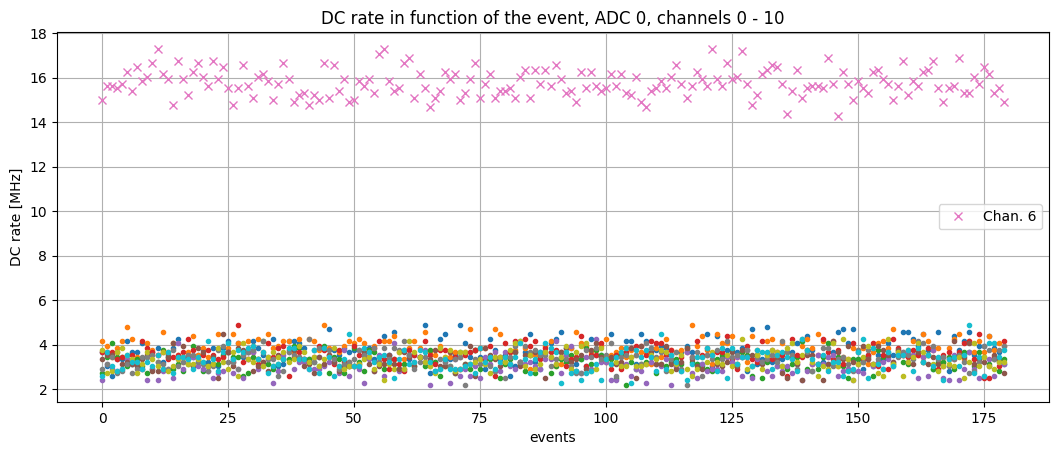

In [26]:
fig_DCrate_events = plt.figure(figsize=[12.8, 4.8])
ax_DCrate_events = fig_DCrate_events.subplots()

ax_DCrate_events.set_xlabel('events')
ax_DCrate_events.set_ylabel('DC rate [MHz]')
ax_DCrate_events.grid(True)

leg_list = []

for event in range(Nevent):
    for adc in range(1):
        for chan in range(10):
            if (wvfms2.Npeaks[event,adc,chan]*10**-6/(600*wvfms2.time_tick)<8):
                ax_DCrate_events.plot(event, wvfms2.Npeaks[event,adc,chan]*10**-6/(600*wvfms2.time_tick), marker='.')
            else:
                if (np.isin(chan, leg_list)==False):
                    ax_DCrate_events.plot(event, wvfms2.Npeaks[event,adc,chan]*10**-6/(600*wvfms2.time_tick), marker='x', ls='', label=f'Chan. {chan}')
                    leg_list.append(chan)
                else:
                    ax_DCrate_events.plot(event, wvfms2.Npeaks[event,adc,chan]*10**-6/(600*wvfms2.time_tick), marker='x')

ax_DCrate_events.set_title('DC rate in function of the event, ADC 0, channels 0 - 10')
ax_DCrate_events.legend()

36 peaks were found above the mean with a minWidth of 5 and 51 were cut out.


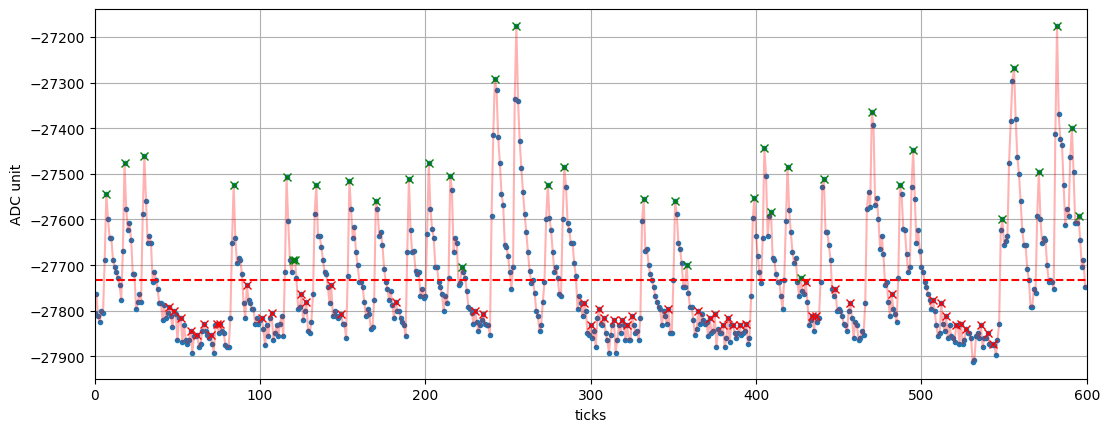

In [27]:
wvfms2.plot_wvfms(13, 0, 10, (00,600), peakFinder=True, minWidth=5, verbose=True)

28 peaks were found above the mean with a minWidth of 9 and 16 were cut out.


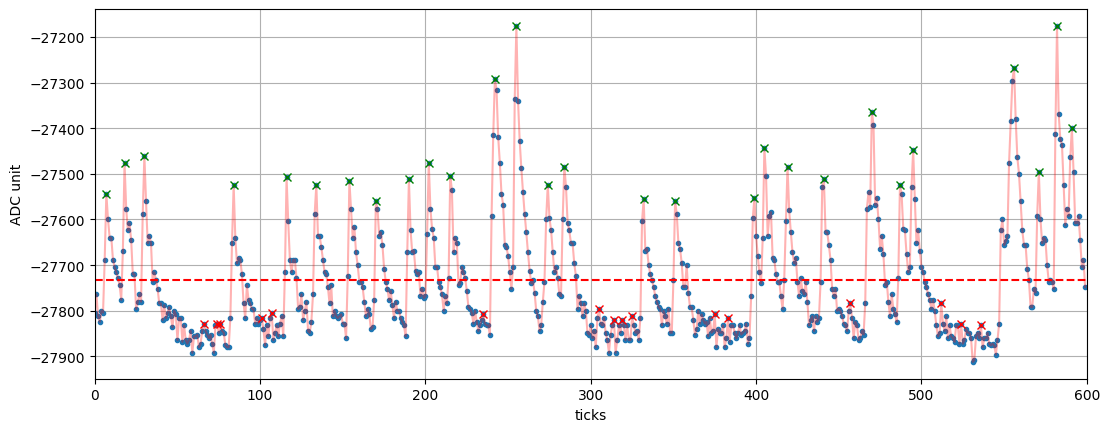

In [28]:
wvfms.plot_wvfms(13, 0, 10, (00,600), peakFinder=True, minWidth=9, verbose=True)

[ 8.31725365e+02 -2.69521113e+04  1.69192720e+01  2.45579592e+02
 -2.68748464e+04 -2.88365822e+01  2.22311493e+02 -2.67993857e+04
  2.15650494e+02]


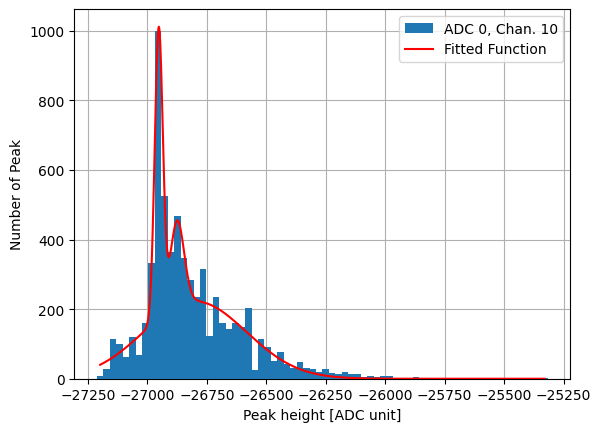

In [29]:
wvfms.fingerPlot_Amp_wvfms(Nbins=70)

## Look at the baseline
These baseline measurements were taken without bias voltage to avoid SiPM darkcounts. 6 runs were taken after different procedure to check that the baseline is constant.

In [30]:
# First get the data
f_108_p0 = '20250516_calib_rctl_108_p0.flow.h5'
f_108_p1 = '20250516_calib_rctl_108_p1.flow.h5'
f_108_p2 = '20250516_calib_rctl_108_p2.flow.h5'
f_109_p0 = '20250516_calib_rctl_109_p0.flow.h5'
f_110_p0 = '20250516_calib_rctl_110_p0.flow.h5'
f_111_p0 = '20250516_calib_rctl_111_p0.flow.h5'

f_baseline= [f_108_p0, f_108_p1, f_108_p2, f_109_p0, f_110_p0, f_111_p0]

In [31]:
wvfms_108_p0 = calibWvfms(filedir = d, filename = f_108_p0)

Processing file /Users/nsallin/develop/data/FSD/test_ndlar_flow/20250516_calib_rctl_108_p0.flow.h5
The output path is set to /Users/nsallin/develop/calibFSD/evD_20250516_calib_rctl_108_p0.flow.h5/
Number of events in the selection: 539


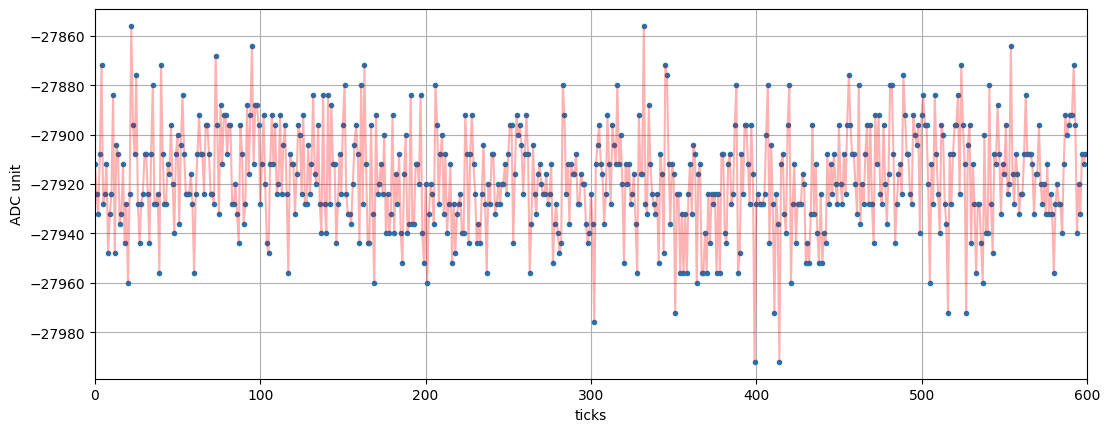

In [32]:
wvfms_108_p0.plot_wvfms(13, 0, 10, (00,600))

In [33]:
wvfms_108_p1 = baselineWvfms(filedir = d, filename = f_108_p1)

Processing file /Users/nsallin/develop/data/FSD/test_ndlar_flow/20250516_calib_rctl_108_p1.flow.h5
The output path is set to /Users/nsallin/develop/calibFSD/evD_20250516_calib_rctl_108_p1.flow.h5/
Number of events in the selection: 181


In [34]:
wvfms_108_p1.compute_baselines()

In [35]:
wvfms_108_p1.baselines.shape

(181, 4, 64)

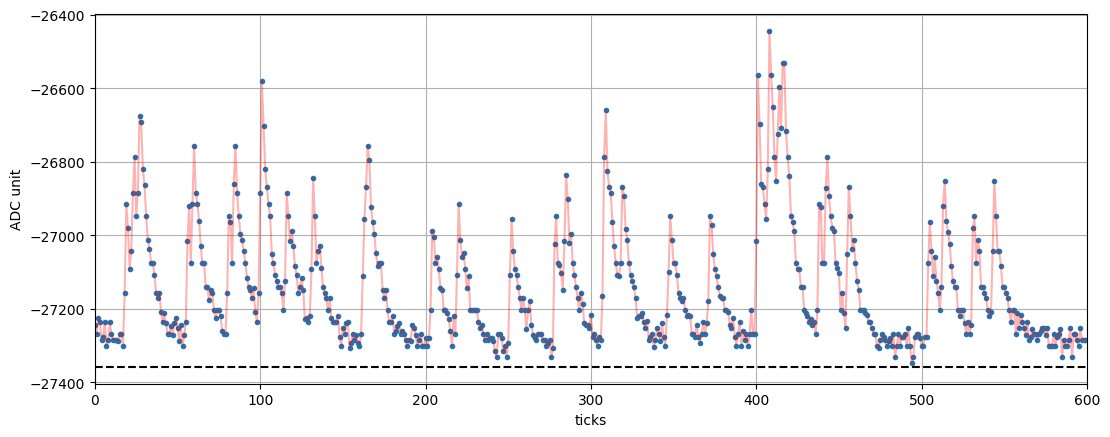

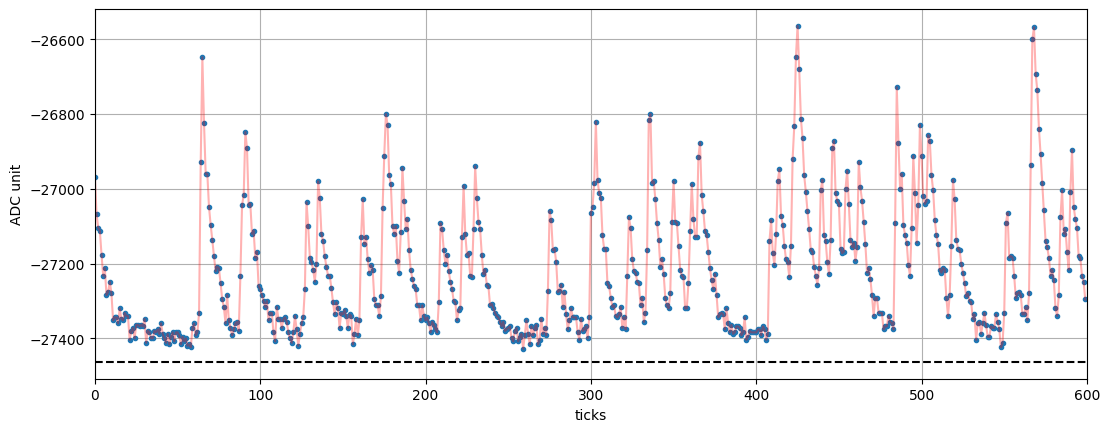

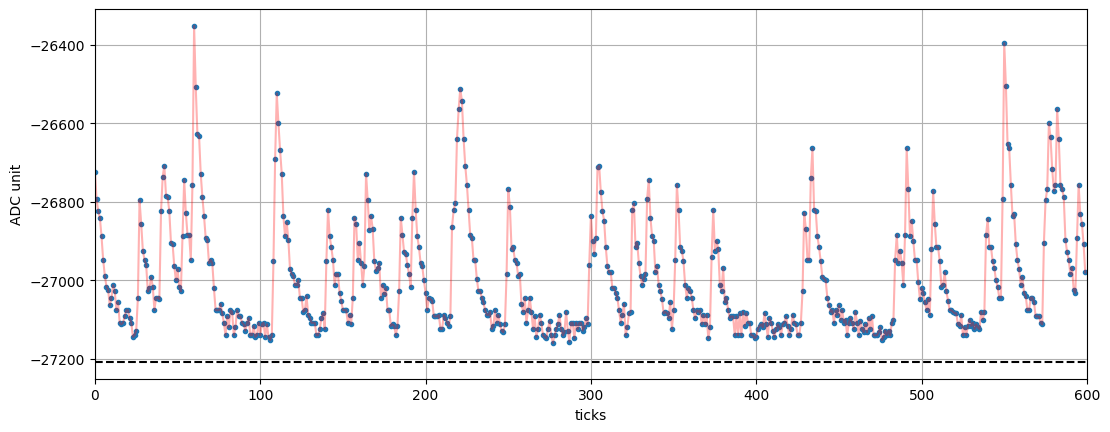

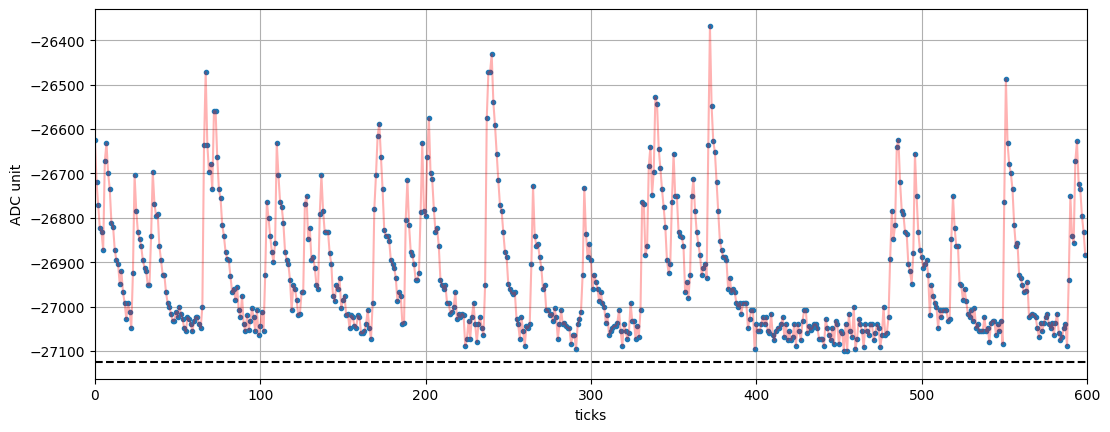

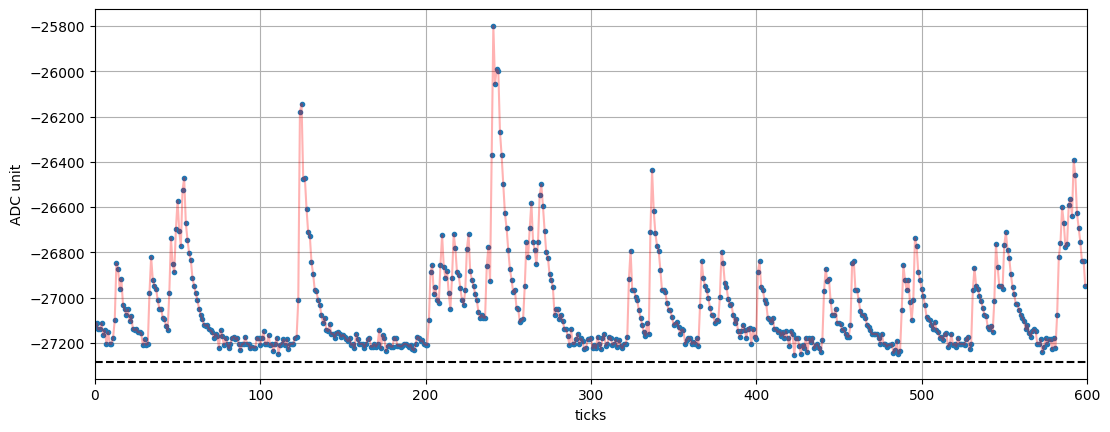

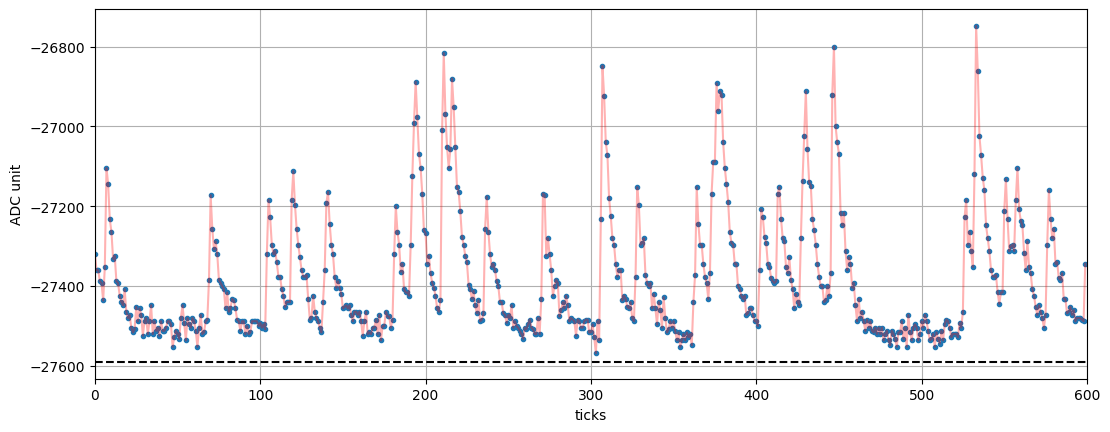

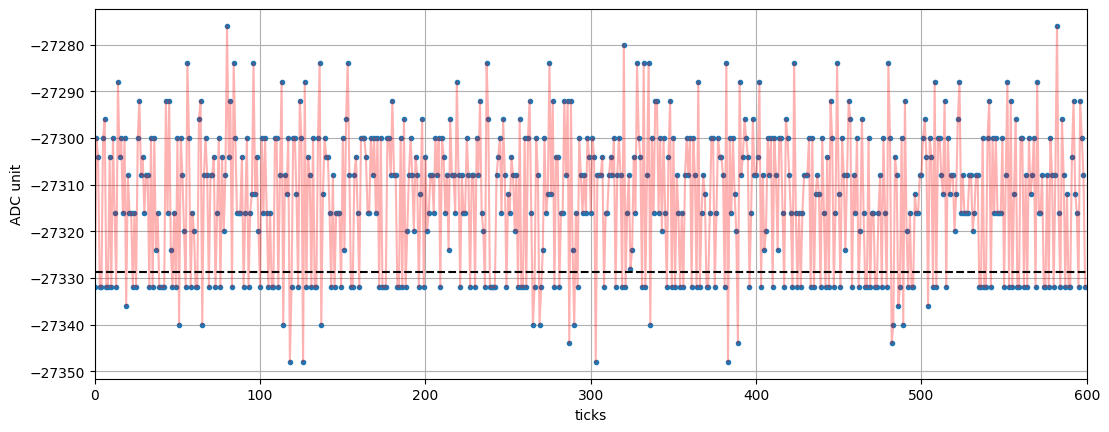

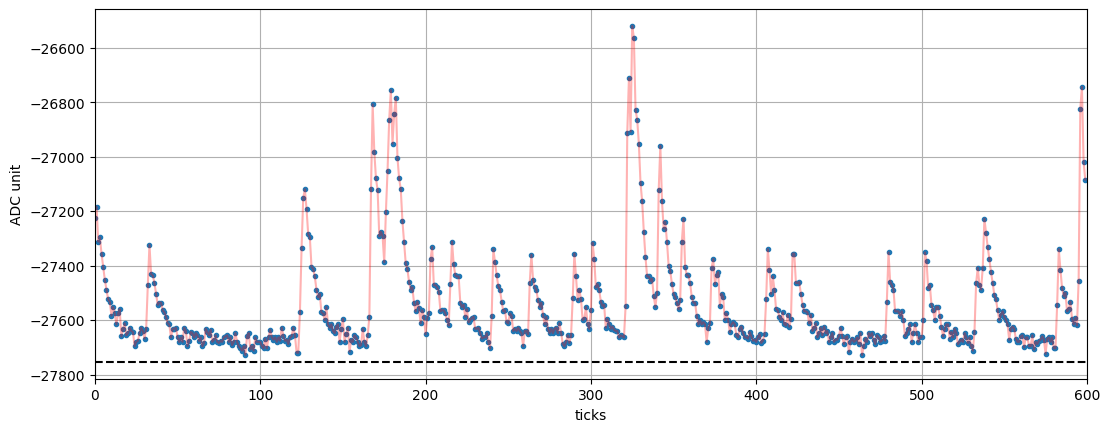

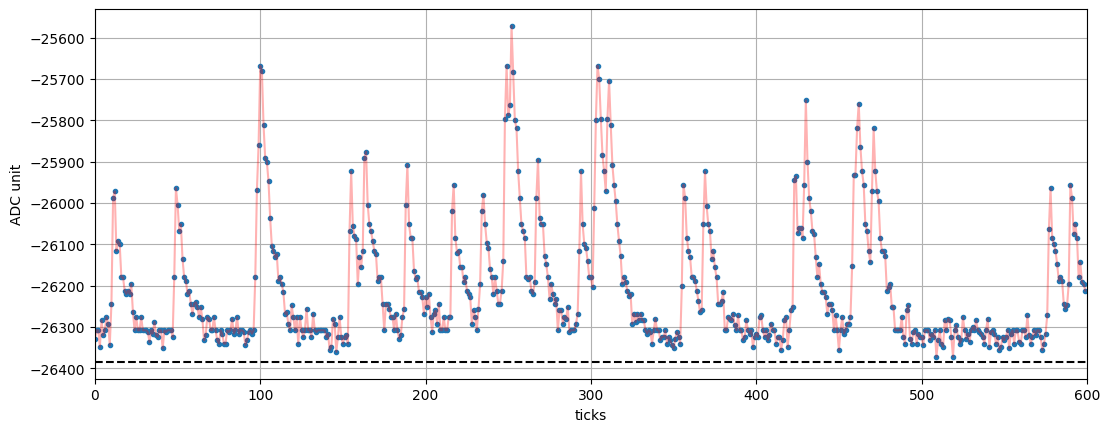

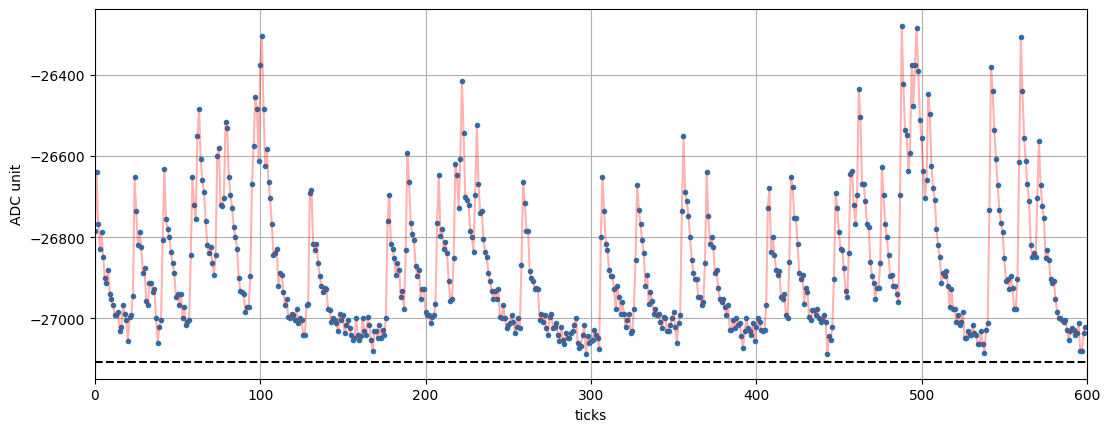

In [36]:
for chan in range(10):
    wvfms.plot_wvfms(13, 0, chan, (00,600), baseline=np.mean(wvfms_108_p1.baselines, axis=0)[0,chan])

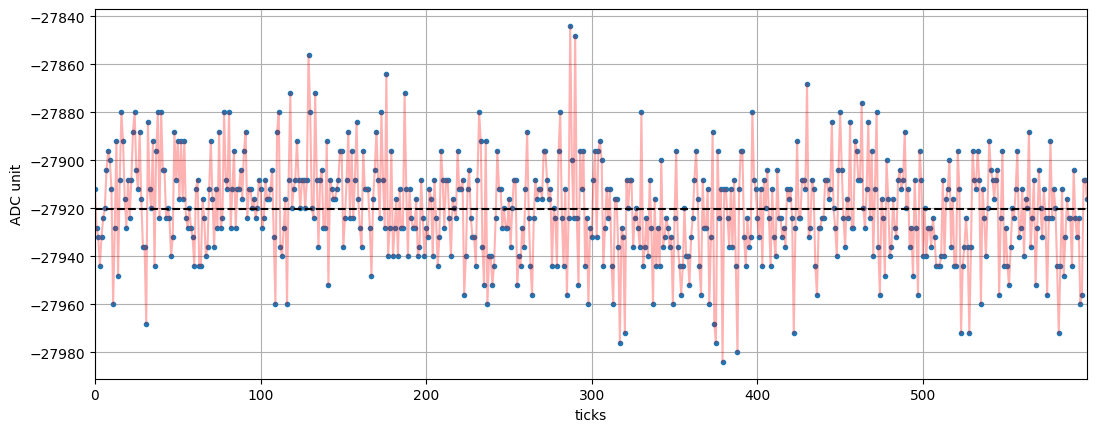

In [37]:
wvfms_108_p1.plot_wvfms(13, 0, 10)

-27327.133333333335


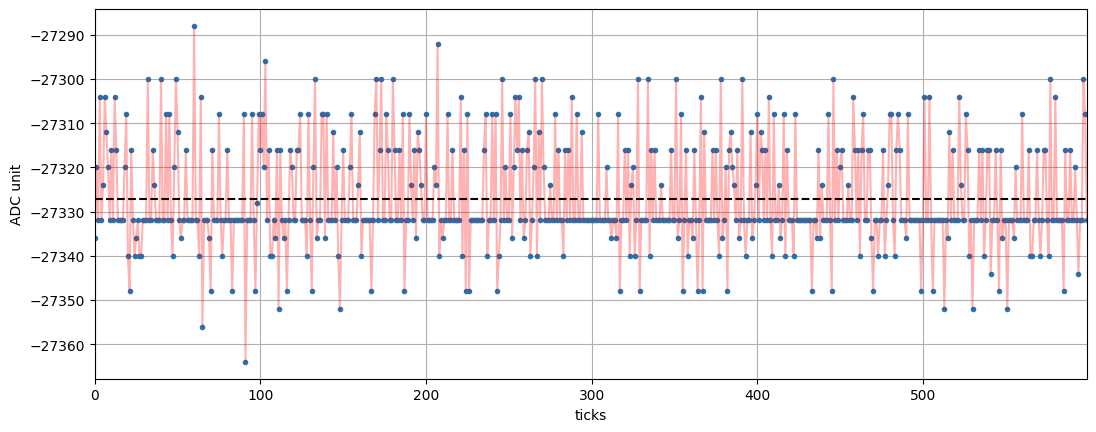

In [38]:
wvfms_108_p1.plot_wvfms(13, 0, 6)
print(wvfms_108_p1.baselines[13, 0, 6])

np.float64(-27313.153333333332)

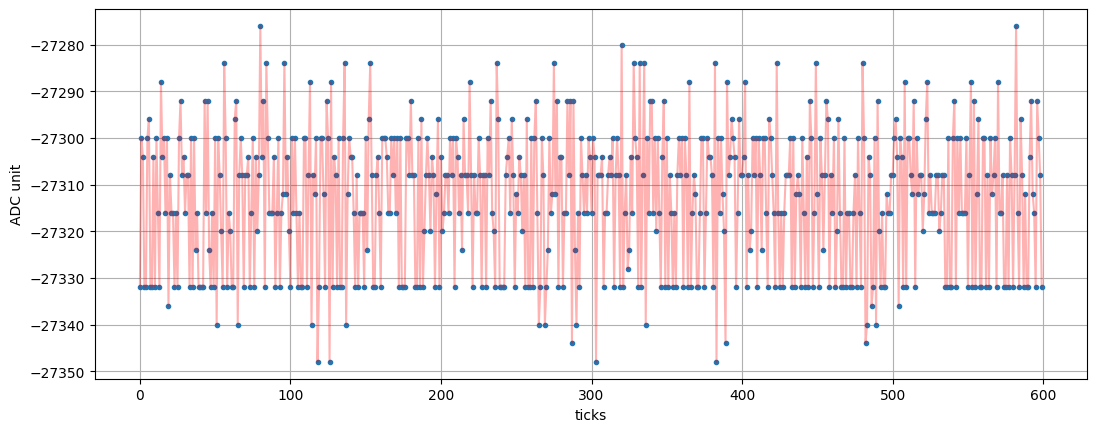

In [39]:
wvfms.plot_wvfms(13, 0, 6)
np.mean(wvfms.light_wvfms[13, 0, 6])

Processing file /Users/nsallin/develop/data/FSD/test_ndlar_flow/20250516_calib_rctl_108_p0.flow.h5
The output path is set to /Users/nsallin/develop/calibFSD/evD_20250516_calib_rctl_108_p0.flow.h5/
Number of events in the selection: 539
Processing file /Users/nsallin/develop/data/FSD/test_ndlar_flow/20250516_calib_rctl_108_p1.flow.h5
The output path is set to /Users/nsallin/develop/calibFSD/evD_20250516_calib_rctl_108_p1.flow.h5/
Number of events in the selection: 181
Processing file /Users/nsallin/develop/data/FSD/test_ndlar_flow/20250516_calib_rctl_108_p2.flow.h5
The output path is set to /Users/nsallin/develop/calibFSD/evD_20250516_calib_rctl_108_p2.flow.h5/
Number of events in the selection: 56
Processing file /Users/nsallin/develop/data/FSD/test_ndlar_flow/20250516_calib_rctl_109_p0.flow.h5
The output path is set to /Users/nsallin/develop/calibFSD/evD_20250516_calib_rctl_109_p0.flow.h5/
Number of events in the selection: 179
Processing file /Users/nsallin/develop/data/FSD/test_ndla

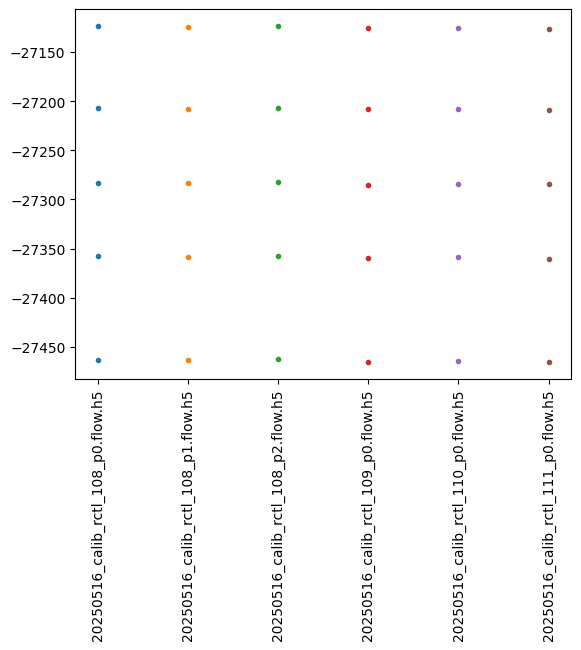

In [40]:
fig_BLs = plt.figure()#figsize=[12.8, 4.8])
ax_BLs = fig_BLs.subplots()


for file in f_baseline:
    x_names = np.full(64, file)
    blsWvfms = baselineWvfms(filedir = d, filename = file)
    blsWvfms.compute_baselines()
    baselines = np.mean(blsWvfms.baselines, axis=0)
    # for adc in range(Nadc):
    ax_BLs.plot(x_names[0:5], baselines[0][0:5], marker='.', ls='')

ax_BLs.tick_params(axis='x', labelrotation=90)
    

In [41]:
import numpy as np

In [42]:
np.arange(179, 119, -1)

array([179, 178, 177, 176, 175, 174, 173, 172, 171, 170, 169, 168, 167,
       166, 165, 164, 163, 162, 161, 160, 159, 158, 157, 156, 155, 154,
       153, 152, 151, 150, 149, 148, 147, 146, 145, 144, 143, 142, 141,
       140, 139, 138, 137, 136, 135, 134, 133, 132, 131, 130, 129, 128,
       127, 126, 125, 124, 123, 122, 121, 120])

In [43]:
def find_correct_chan(wrong_map, correct_map, wrong_i, wrong_j):
    """
    Given a position (wrong_i, wrong_j) in the wrong map, find where the same value appears in the correct map.

    Parameters:
        wrong_map (list[list[int]]): Original incorrect mapping
        correct_map (list[list[int]]): Correct mapping
        wrong_i (int): Row index in wrong_map
        wrong_j (int): Column index in wrong_map

    Returns:
        (int, int): Indices in the correct_map where the value is found
                    or None if not found
    """
    target_val = wrong_map[wrong_i][wrong_j]

    if target_val == -1:
        return None  # Ignore placeholder

    for i, row in enumerate(correct_map):
        for j, val in enumerate(row):
            if val == target_val:
                return i, j
    return None  # Not found

In [44]:
wrong_map = [[180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, -1, -1, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239,
      -1, -1],
      [179, 178, 177, 176, 175, 174, 173, 172, 171, 170, 169, 168, 167, 166, 165, 164, 163, 162, 161, 160, 159, 158, 157, 156, 155, 154, 153, 152, 151, 150,
      -1, -1,
      149, 148, 147, 146, 145, 144, 143, 142, 141, 140, 139, 138, 137, 136, 135, 134, 133, 132, 131, 130, 129, 128, 127, 126, 125, 124, 123, 122, 121, 120,
      -1, -1],
      [119, 118, 117, 116, 115, 114, 113, 112, 111, 110, 109, 108, 107, 106, 105, 104, 103, 102, 101, 100, 99, 98, 97, 96, 95, 94, 93, 92, 91, 90,
      -1, -1,
      89, 88, 87, 86, 85, 84, 83, 82, 81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60,
      -1, -1],
      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
      -1, -1,
      30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59,
      -1, -1]]

correct_map = [[119, 118, 117, 116, 115, 114, 113, 112, 111, 110, 109, 108, 107, 106, 105, 104, 103, 102, 101, 100, 99, 98, 97, 96, 95, 94, 93, 92, 91, 90,
      -1, -1,
      89, 88, 87, 86, 85, 84, 83, 82, 81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60,
      -1, -1],
      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
      -1, -1,
      30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59,
      -1, -1],
      [120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
      -1, -1,
      150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,
      -1, -1],
     [239, 238, 237, 236, 235, 234, 233, 232, 231, 230, 229, 228, 227, 226, 225, 224, 223, 222, 221, 220, 219, 218, 217, 216, 215, 214, 213, 212, 211, 210,
      -1, -1,
      209, 208, 207, 206, 205, 204, 203, 202, 201, 200, 199, 198, 197, 196, 195, 194, 193, 192, 191, 190, 189, 188, 187, 186, 185, 184, 183, 182, 181, 180,
      -1, -1]]

In [45]:
for wrong_adc in range(4):
    for wrong_chan in range(64):
        if wrong_map[wrong_adc][wrong_chan] != -1 :
            correct_adc, correct_chan = find_correct_chan(wrong_map, correct_map, wrong_adc, wrong_chan)
            print(f'{wrong_adc}, {wrong_chan}: {correct_map[correct_adc][correct_chan]==wrong_map[wrong_adc][wrong_chan]}')

0, 0: True
0, 1: True
0, 2: True
0, 3: True
0, 4: True
0, 5: True
0, 6: True
0, 7: True
0, 8: True
0, 9: True
0, 10: True
0, 11: True
0, 12: True
0, 13: True
0, 14: True
0, 15: True
0, 16: True
0, 17: True
0, 18: True
0, 19: True
0, 20: True
0, 21: True
0, 22: True
0, 23: True
0, 24: True
0, 25: True
0, 26: True
0, 27: True
0, 28: True
0, 29: True
0, 32: True
0, 33: True
0, 34: True
0, 35: True
0, 36: True
0, 37: True
0, 38: True
0, 39: True
0, 40: True
0, 41: True
0, 42: True
0, 43: True
0, 44: True
0, 45: True
0, 46: True
0, 47: True
0, 48: True
0, 49: True
0, 50: True
0, 51: True
0, 52: True
0, 53: True
0, 54: True
0, 55: True
0, 56: True
0, 57: True
0, 58: True
0, 59: True
0, 60: True
0, 61: True
1, 0: True
1, 1: True
1, 2: True
1, 3: True
1, 4: True
1, 5: True
1, 6: True
1, 7: True
1, 8: True
1, 9: True
1, 10: True
1, 11: True
1, 12: True
1, 13: True
1, 14: True
1, 15: True
1, 16: True
1, 17: True
1, 18: True
1, 19: True
1, 20: True
1, 21: True
1, 22: True
1, 23: True
1, 24: True
